Simulando trayectoria a través de 3 medios...
----------------------------------------
INTERFASE 1 (n=1.0 -> n=1.5)
Punto cruce: (4.67, 4.72)
Comprobación Snell: 0.9991
----------------------------------------
INTERFASE 2 (n=1.5 -> n=1.33)
Punto cruce: (6.43, -3.21)
Comprobación Snell: 1.0318
----------------------------------------


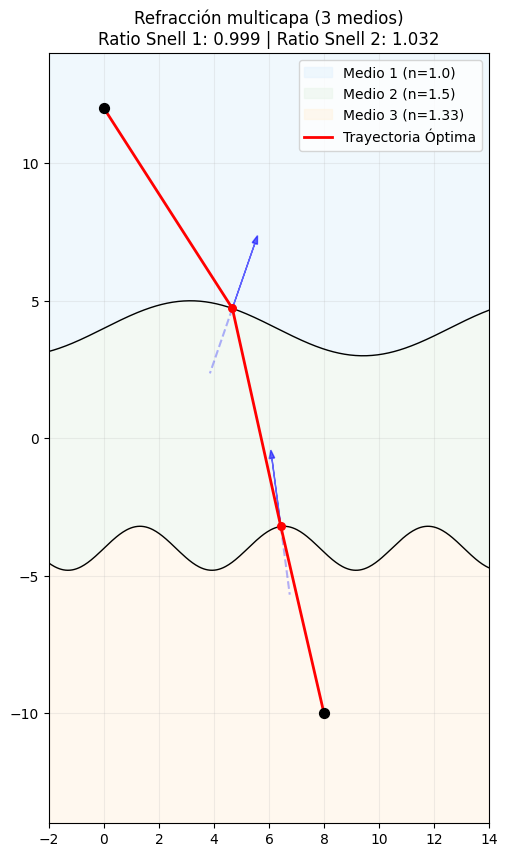

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
c = 1.0

# Índices de refracción (Ejemplo: Aire -> Vidrio -> Agua)
n1 = 1.0   # Aire (Superior)
n2 = 1.5   # Vidrio (Medio)
n3 = 1.33  # Agua (Inferior)

# Coordenadas
origen = (0, 12)       # Punto A (En medio 1)
destino = (8, -10)    # Punto B (En medio 3)

intentos = 200000      # Más intentos porque hay 2 variables a optimizar

# ==========================================
# 2. DEFINICIÓN DE LAS 2 INTERFASES
# ==========================================

# Interfase SUPERIOR (entre n1 y n2) -> Alrededor de y = 4
def f_interfase_1(x):
    # Una onda suave
    return 4.0 + 1.0 * np.sin(0.5 * x)

def df_interfase_1(x):
    return 0.5 * np.cos(0.5 * x) # Derivada

# Interfase INFERIOR (entre n2 y n3) -> Alrededor de y = -4
def f_interfase_2(x):
    # Una onda más rápida (rugosa)
    return -4.0 + 0.8 * np.sin(1.2 * x)

def df_interfase_2(x):
    return 0.8 * 1.2 * np.cos(1.2 * x) # Derivada

# ==========================================
# 3. MONTECARLO "DOBLE"
# ==========================================

def simular_tres_medios(n1, n2, n3, A, B, intentos):
    print("Simulando trayectoria a través de 3 medios...")

    # Rango de búsqueda
    x_min = min(A[0], B[0]) - 2
    x_max = max(A[0], B[0]) + 2

    # Generamos PARES aleatorios (x1 para la frontera 1, x2 para la frontera 2)
    # x1: punto de cruce arriba
    x1_rand = np.random.uniform(x_min, x_max, intentos)
    y1_rand = f_interfase_1(x1_rand)

    # x2: punto de cruce abajo
    x2_rand = np.random.uniform(x_min, x_max, intentos)
    y2_rand = f_interfase_2(x2_rand)

    # --- CÁLCULO DE DISTANCIAS ---

    # Tramo 1: Origen -> Frontera 1
    d1 = np.sqrt((x1_rand - A[0])**2 + (y1_rand - A[1])**2)

    # Tramo 2: Frontera 1 -> Frontera 2 (Viaje interno)
    d2 = np.sqrt((x2_rand - x1_rand)**2 + (y2_rand - y1_rand)**2)

    # Tramo 3: Frontera 2 -> Destino
    d3 = np.sqrt((B[0] - x2_rand)**2 + (B[1] - y2_rand)**2)

    # --- TIEMPO TOTAL ---
    # t = (d1*n1 + d2*n2 + d3*n3) / c
    ts = (d1 * n1 + d2 * n2 + d3 * n3) / c

    # Encontrar el mínimo
    idx = np.argmin(ts)

    # Puntos ganadores
    p1 = (x1_rand[idx], y1_rand[idx])
    p2 = (x2_rand[idx], y2_rand[idx])

    return p1, p2, ts[idx]

# Ejecutar
p1, p2, t_min = simular_tres_medios(n1, n2, n3, origen, destino, intentos)

# ==========================================
# 4. CÁLCULOS FÍSICOS (VERIFICACIÓN)
# ==========================================

def comprobar_snell(punto_incidencia, origen_rayo, destino_rayo, n_in, n_out, pendiente_sup):
    # Vector Normal Local (-pendiente, 1)
    normal = np.array([-pendiente_sup, 1.0])
    normal = normal / np.linalg.norm(normal)

    # Vector Entrante (Inverso al movimiento)
    v_in = np.array([punto_incidencia[0] - origen_rayo[0], punto_incidencia[1] - origen_rayo[1]])
    v_in_u = v_in / np.linalg.norm(v_in)

    # Vector Saliente
    v_out = np.array([destino_rayo[0] - punto_incidencia[0], destino_rayo[1] - punto_incidencia[1]])
    v_out_u = v_out / np.linalg.norm(v_out)

    # Ángulos respecto a la normal (producto punto)
    # OJO: La orientación de la normal puede variar, usamos abs para el ángulo agudo
    theta_1 = np.arccos(np.abs(np.dot(v_in_u, normal)))
    theta_2 = np.arccos(np.abs(np.dot(v_out_u, normal)))

    ratio = (n_in * np.sin(theta_1)) / (n_out * np.sin(theta_2))
    return theta_1, theta_2, ratio, normal

# -- Comprobar Interfase 1 (Arriba) --
m1 = df_interfase_1(p1[0])
t1_in, t1_out, ratio1, norm1 = comprobar_snell(p1, origen, p2, n1, n2, m1)

# -- Comprobar Interfase 2 (Abajo) --
m2 = df_interfase_2(p2[0])
t2_in, t2_out, ratio2, norm2 = comprobar_snell(p2, p1, destino, n2, n3, m2)

print("-" * 40)
print(f"INTERFASE 1 (n={n1} -> n={n2})")
print(f"Punto cruce: ({p1[0]:.2f}, {p1[1]:.2f})")
print(f"Comprobación Snell: {ratio1:.4f}")
print("-" * 40)
print(f"INTERFASE 2 (n={n2} -> n={n3})")
print(f"Punto cruce: ({p2[0]:.2f}, {p2[1]:.2f})")
print(f"Comprobación Snell: {ratio2:.4f}")
print("-" * 40)

# ==========================================
# 5. GRÁFICA
# ==========================================
plt.figure(figsize=(10, 10))

x_plot = np.linspace(-5, 15, 500)
y_sup1 = f_interfase_1(x_plot)
y_sup2 = f_interfase_2(x_plot)

# -- Dibujar Medios (Colores) --
# Medio 1 (Arriba de todo)
plt.fill_between(x_plot, y_sup1, 15, color='#E3F2FD', alpha=0.5, label=f'Medio 1 (n={n1})')
# Medio 2 (Sandwich)
plt.fill_between(x_plot, y_sup2, y_sup1, color='#E8F5E9', alpha=0.5, label=f'Medio 2 (n={n2})')
# Medio 3 (Abajo de todo)
plt.fill_between(x_plot, -15, y_sup2, color='#FFF3E0', alpha=0.5, label=f'Medio 3 (n={n3})')

# -- Dibujar Superficies --
plt.plot(x_plot, y_sup1, 'k-', linewidth=1)
plt.plot(x_plot, y_sup2, 'k-', linewidth=1)

# -- Dibujar Rayo de Luz --
plt.plot([origen[0], p1[0], p2[0], destino[0]],
         [origen[1], p1[1], p2[1], destino[1]],
         color='red', linewidth=2, label='Trayectoria Óptima', zorder=10)

# -- Dibujar Normales (Flechas azules) --
scale = 2.5
# Normal 1
plt.arrow(p1[0], p1[1], norm1[0]*scale, norm1[1]*scale, head_width=0.2, color='blue', alpha=0.6)
plt.plot([p1[0], p1[0]-norm1[0]*scale], [p1[1], p1[1]-norm1[1]*scale], 'b--', alpha=0.3)

# Normal 2
plt.arrow(p2[0], p2[1], norm2[0]*scale, norm2[1]*scale, head_width=0.2, color='blue', alpha=0.6)
plt.plot([p2[0], p2[0]-norm2[0]*scale], [p2[1], p2[1]-norm2[1]*scale], 'b--', alpha=0.3)

# Puntos
plt.scatter(*origen, c='black', s=50, zorder=10)
plt.scatter(*destino, c='black', s=50, zorder=10)
plt.scatter(*p1, c='red', s=30, zorder=10)
plt.scatter(*p2, c='red', s=30, zorder=10)

plt.title(f"Refracción multicapa (3 medios)\nRatio Snell 1: {ratio1:.3f} | Ratio Snell 2: {ratio2:.3f}")
plt.xlim(-2, 14)
plt.ylim(-14, 14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.gca().set_aspect('equal')

plt.show()